# Importing Libraries

In [450]:
import random
import rustworkx as rx
import numpy as np

# Generating Memory Network

The first step is to create our memories. 

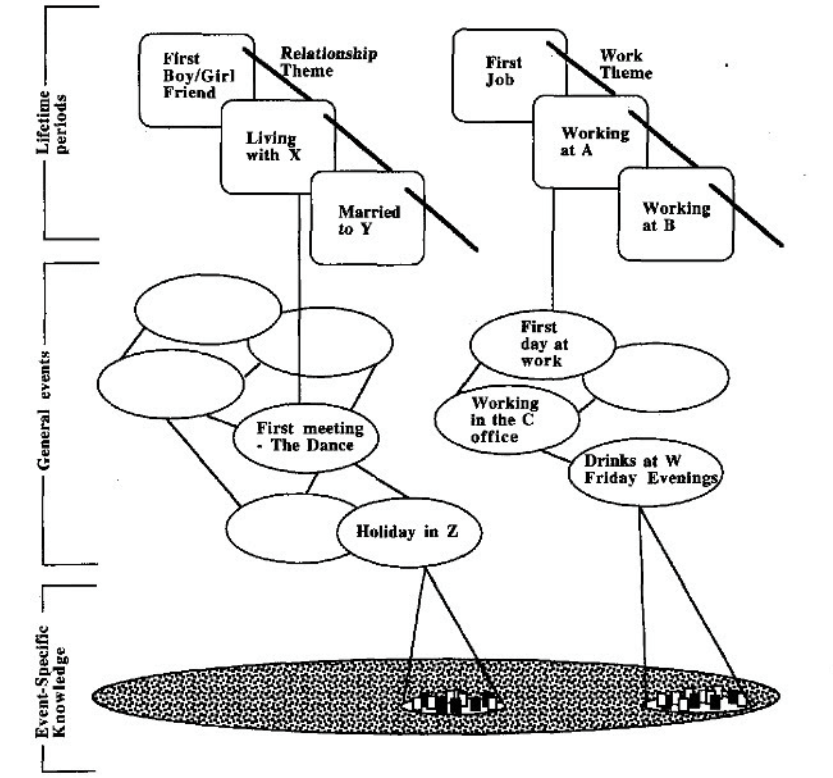

According to Conway and Pearce (2000), autobiographical memory can be divided into three main components: 

- lifetime periods ("When I was younger")
- general events ("I went on a trip during summer break")
- event specific knowledge (ESK) ("I smelled the smoke of the wildfire")

For this model, we will be focusing on the lowest layer (ESK), as that is what people with OGM often have trouble remembering. The goal is to create an undirected graph with the following properties:

- Every node is an individual ESK, and is connected to every other node
- Each node has a base-level activation that decays over time and spikes whenever it is retrieved.
- The edges contain weights which represent how closely associated two memories are. This is the spreading activation.

## Spreading Activation

In the spreading activation model of memory retrieval, activation of one node causes activation of a connected node which repeats until retrieval is terminated through some process. It makes sense then that nodes which are more closely connected (ESK's of the same general event) would be more likely to activate each other than ESK's that are unrelated.

![Spreading Activation](Spreading-activation-graph-1.png)

To calculate the probability of a memory being retrieved, we would first have to consider the total activation of every node, defined as the base-level activation + spreading activation + noise. Then, the model would probabilistically choose a node that is above a pre-defined threshold using the activations as the weights.

## ACT-R Model of Memory Decay

Although the spreading activation is assumed to remain constant in this model, the base-level activation changes depending on the number of traces created and the amount of time that has passed. 

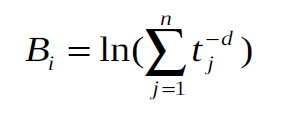

The equation above shows how these are calculated, and it is what my model uses.

In [318]:
class Memory:
    def __init__(self, n, groups, state, thres=0.1, sigma=0.1):
        group_size = n // groups

        def weight(i, j):
            return 10 if (i // group_size == j // group_size) else 0

        graph = rx.PyGraph()
        graph.add_nodes_from([[1]] * n)
        graph.add_edges_from([
            (i, j, weight(i, j))
            for i in range(n)
            for j in range(i + 1, n)
        ])
        self.graph = graph
        self.state = state
        self.thres = thres
        self.current_graph = graph.copy()
        self.sigma = sigma

    def spreading_activation(self):
        graph = self.current_graph
        adj = graph.adj(self.state)
        neighbors = list(adj.keys())
        activations = []
        for j in neighbors:
            activation = adj[j] + sum(graph[j]) + random.gauss(0, self.sigma)
            if activation > self.thres:
                activations.append(activation)
            else:
                activations.append(0)
        if sum(activations) == 0:
            return False
        next_state = random.choices(neighbors, weights=activations, k=1)[0]
        self.graph[next_state] = self.graph[next_state] + [1]
        graph.remove_node(self.state)
        return next_state

    def decay(self, time):
        for node in self.graph.node_indices():
            self.graph[node] = [trace * time ** -0.5 for trace in self.graph[node]]

# Agent

In reinforcement learning, an agent learns to explore its environment in order to maximize rewards. This is what that means in terms of my model:

- Environment: The memory network defined in the previous section.
- Agent: Decision-making process in the brain that decides whether to continue or terminate retrieval.
- Reward: How useful (or traumatic) a memory is.

To simplify the model, I will assume that there is one "trauma" memory which has a very negative reward, and all of the other memories have small positive rewards.

The way that the agent makes the decision to continue or terminate depends on what the agent expects the reward to be at its current node, also known as the *value*. It keeps track of these values in a *v-table* which gets built up over time as the agent explores more and more of its network.

# Parameters

WIP

In [439]:
class Agent:
    def __init__(self, alpha=0.1, gamma=0.9, temp=0.1):
        self.alpha = alpha
        self.gamma = gamma
        self.temp = temp
        self.vtable = {}
        self.reason = None
    
    def policy(self, network):
        s1 = network.state
        if s1 not in self.vtable:
            self.vtable[s1] = 1
        v1 = self.vtable[s1]
        recall = 1 / (1 + np.e ** (-v1 / self.temp)) > random.random()
        if recall:
            s2 = network.spreading_activation()
            if s2 is False:
                self.reason = "No activation above threshold"
                return False
            network.state = s2
        else:
            self.reason = "Value is too low"
            return False
        if s2 not in self.vtable:
            self.vtable[s2] = 1
        v2 = self.vtable[s2]
        r = -10 if s2 == 0 else 1 # hardcoding memory 0 as "trauma" memory
        rpe = r + self.gamma * v2 - v1
        self.vtable[s1] += self.alpha * rpe
        return True

# Simulator

To run the agent in the envrionment multiple times, I have created a simulator class that defines methods for a single retrieval, and multiple retrievals.

In [430]:
class Simulator:
    def __init__(self, agent, network):
        self.states_visited = []
        self.record = []
        self.agent = agent
        self.network = network
    
    def retrieve(self, max_steps, decay, time):
        recall = True
        steps = 0
        self.network.current_graph = self.network.graph.copy()
        while recall and steps < max_steps:
            self.states_visited.append(self.network.state)
            recall = self.agent.policy(self.network)
            steps += 1
        if decay:
            self.network.decay(time)

    def run(self, n, max_steps, decay=True, time=10):
        for _ in range(n):
            self.retrieve(max_steps, decay, time)
            self.record.append(self.states_visited)
            self.states_visited = []

# Testing

In [449]:
environment = Memory(100, 20, 99, thres=1, sigma=0.5)
agent = Agent()
test = Simulator(agent, environment)
test.run(10, 99, time=10)
for trial in test.record:
    print(len(trial))
print(dict(sorted(agent.vtable.items())))

98
93
77
1
23
10
18
41
40
67
{0: 1.34363147842, 1: 0.5240987974810001, 2: 0.6178225347981485, 3: 0.32253341488099996, 4: 0.47403412444000004, 5: 1.187119, 6: 1.4280143957839, 7: 1.3539142, 8: 1.187119, 9: 1.35801798031612, 10: 1.35463591, 11: 1.35463591, 12: 1.4410895509000001, 13: 1.4550145473846718, 14: 1.36950385771, 15: 1.5645412838467179, 16: 1.2455381984457514, 17: 1.568578646648605, 18: 1.5270585553580256, 19: 1.6498387933072454, 20: 1.27524781, 21: 1.267309, 22: 1.267309, 23: 1.3466971, 24: 1.35463591, 25: 1.4744444886712, 26: 1.421661189871, 27: 1.514635139449, 28: 1.581975091441, 29: 1.4528397114100002, 30: 1.3466971, 31: 1.35463591, 32: 1.35463591, 33: 1.35463591, 34: 1.27524781, 35: 1.267309, 36: 1.267309, 37: 1.267309, 38: 1.267309, 39: 1.267309, 40: 1.4410895509000001, 41: 1.4339446219, 42: 1.440375058, 43: 1.267309, 44: 1.432574029, 45: 1.34807491, 46: 1.35463591, 47: 1.36197375857839, 48: 1.260019, 49: 1.28902591, 50: 1.09, 51: 1.2665071, 52: 1.09, 53: 1.26722881, 54: 1